In [1]:
import torch
import matplotlib.pyplot as plt
import torchvision
from torchvision.transforms import ToTensor
from torchvision import datasets

In [2]:
torchvision.__version__, torch.__version__

('0.28.0+cu126', '2.13.0+cu126')

In [3]:
train_data = datasets.FashionMNIST(
    root="data",
    train=True, 
    download=True,
    transform=ToTensor(), 
    target_transform=None 
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False, 
    download=True,
    transform=ToTensor()
)

In [4]:
image, label = train_data[0]

In [5]:
image.shape

torch.Size([1, 28, 28])

In [6]:
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [7]:
class_name = train_data.classes
class_name

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

Text(0.5, 1.0, '9')

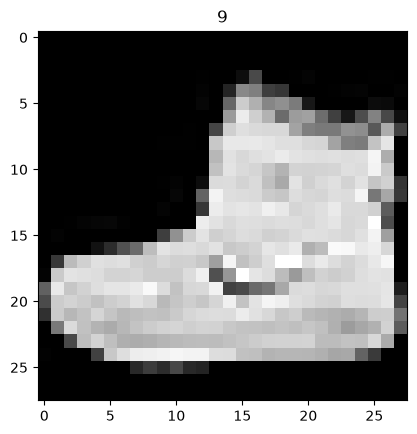

In [8]:
plt.imshow(image.squeeze(), cmap = 'gray')
plt.title(label)

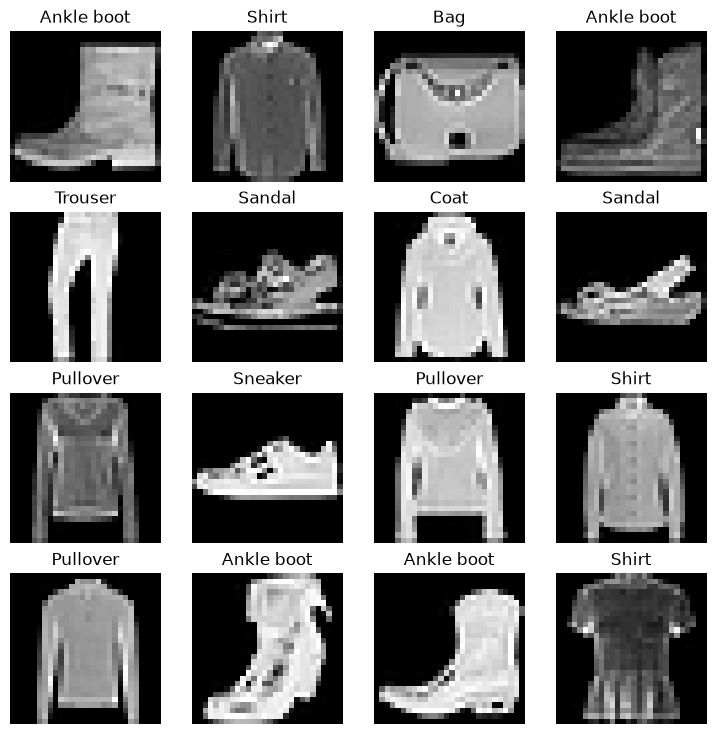

In [9]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_name[label])
    plt.axis(False)

In [10]:
from torch.utils.data import DataLoader

In [11]:
train_dataloader = DataLoader(train_data, batch_size = 32, shuffle = True)
test_dataloader = DataLoader(test_data, batch_size = 32, shuffle = False)

In [12]:
print(f"Dataloaders: {train_dataloader, test_dataloader}") 
print(f"Length of train dataloader: {len(train_dataloader)} batches of {train_dataloader.batch_size}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {test_dataloader.batch_size}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x000002202867ABA0>, <torch.utils.data.dataloader.DataLoader object at 0x0000022028BBB390>)
Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


In [13]:
class nonCNNModel(torch.nn.Module):
    def __init__(self, input_shape: int, output_shape: int):
        super().__init__()

        self.layers = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(in_features = input_shape, out_features = 64),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features = 64, out_features= 32),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features = 32, out_features = output_shape)
        )

    def forward(self, x):
        return self.layers(x)

In [14]:
model = nonCNNModel(input_shape = 784, output_shape = len(class_name))
model

nonCNNModel(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=10, bias=True)
  )
)

In [15]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [16]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model.parameters(), lr = 0.1)

In [17]:
from timeit import default_timer as timer 
def print_train_time(start: float, end: float, device: torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [18]:
from torchmetrics import Accuracy

accuracy = Accuracy(task = 'multiclass', num_classes = len(class_name))

In [19]:
torch.manual_seed(42)

epoch = 10
train_time_start_on_cpu = timer()

for ep in range(epoch):

    print(f'epoch : {ep}')

    train_loss = 0

    for batch, (X, y) in enumerate(train_dataloader):

        model.train()

        y_pred = model(X)

        loss = loss_fn(y_pred, y)

        train_loss += loss

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        if batch % 300 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

    train_loss /= len(train_dataloader)
    test_loss, test_acc = 0, 0 

    model.eval()
    with torch.inference_mode():

        for batch, (X, y) in enumerate(test_dataloader):

            test_pred = model(X)

            test_loss += loss_fn(test_pred, y)

            test_acc += accuracy(test_pred, y)

        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)

    print(f"\nTrain loss: {train_loss:.5f} \t|\t Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu, end=train_time_end_on_cpu, device=str(next(model.parameters()).device)) 
        

epoch : 0
Looked at 0/60000 samples
Looked at 9600/60000 samples
Looked at 19200/60000 samples
Looked at 28800/60000 samples
Looked at 38400/60000 samples
Looked at 48000/60000 samples
Looked at 57600/60000 samples

Train loss: 0.61039 	|	 Test loss: 0.46262, Test acc: 0.83%

epoch : 1
Looked at 0/60000 samples
Looked at 9600/60000 samples
Looked at 19200/60000 samples
Looked at 28800/60000 samples
Looked at 38400/60000 samples
Looked at 48000/60000 samples
Looked at 57600/60000 samples

Train loss: 0.41922 	|	 Test loss: 0.41858, Test acc: 0.85%

epoch : 2
Looked at 0/60000 samples
Looked at 9600/60000 samples
Looked at 19200/60000 samples
Looked at 28800/60000 samples
Looked at 38400/60000 samples
Looked at 48000/60000 samples
Looked at 57600/60000 samples

Train loss: 0.37829 	|	 Test loss: 0.39801, Test acc: 0.86%

epoch : 3
Looked at 0/60000 samples
Looked at 9600/60000 samples
Looked at 19200/60000 samples
Looked at 28800/60000 samples
Looked at 38400/60000 samples
Looked at 4800

In [20]:
gpu_model = nonCNNModel(input_shape = 784, output_shape = len(class_name)).to(device)
gpu_model

nonCNNModel(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=10, bias=True)
  )
)